In [1]:
X = clean.drop(columns=["Severity"])
y = clean["Severity"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts().sort_index())

NameError: name 'clean' is not defined

In [2]:
import pandas as pd

clean = pd.read_pickle("clean_data.pkl")

print(clean.shape)

(100000, 45)


In [3]:
X = clean.drop(columns=["Severity"])
y = clean["Severity"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Features shape: (100000, 44)
Target shape: (100000,)

Target distribution:
Severity
1       98
2    55025
3    44844
4       33
Name: count, dtype: int64


In [4]:
print(X.dtypes.value_counts())

print("\nCategorical columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

print("\nNumeric columns:")
print(X.select_dtypes(include=["number"]).columns.tolist())

str               19
bool              13
float64            9
datetime64[us]     2
int32              1
Name: count, dtype: int64

Categorical columns:
['ID', 'Source', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Day']

Numeric columns:
['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Duration_min', 'Hour']


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_31996\1073923133.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include=["object"]).columns.tolist())


In [5]:
drop_columns = [
    "ID",
    "Description",
    "Street",
    "City",
    "County",
    "Zipcode",
    "Country",
    "Airport_Code",
    "Weather_Timestamp",
    "Start_Time",
    "End_Time"
]

X = clean.drop(columns=["Severity"] + drop_columns)

print("Final feature shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

Final feature shape: (100000, 33)

Features:
['Source', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'State', 'Timezone', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Duration_min', 'Hour', 'Day']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

Training set: (80000, 33)
Test set: (20000, 33)

Training target distribution:
Severity
1       78
2    44020
3    35875
4       27
Name: count, dtype: int64

Test target distribution:
Severity
1       20
2    11005
3     8969
4        6
Name: count, dtype: int64


In [7]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("Categorical features:", categorical_features)
print("\nNumber of categorical features:", len(categorical_features))

print("\nNumeric/Boolean features:", numeric_features)
print("\nNumber of numeric/boolean features:", len(numeric_features))

Categorical features: ['Source', 'State', 'Timezone', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'Day']

Number of categorical features: 10

Numeric/Boolean features: ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Duration_min', 'Hour']

Number of numeric/boolean features: 23


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_31996\1948072829.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [ ]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [12]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [13]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_acc, 4))
print("Macro F1:", round(macro_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7467
Balanced Accuracy: 0.3752
Macro F1: 0.3733

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        20
           2       0.80      0.72      0.76     11005
           3       0.70      0.78      0.73      8969
           4       0.00      0.00      0.00         6

    accuracy                           0.75     20000
   macro avg       0.37      0.38      0.37     20000
weighted avg       0.75      0.75      0.75     20000



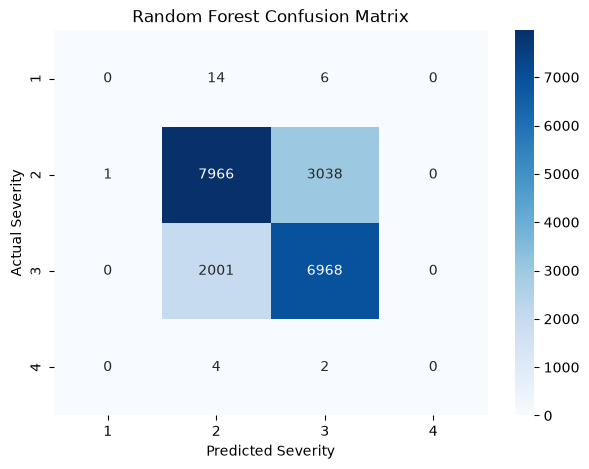

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4],
    yticklabels=[1, 2, 3, 4]
)

plt.xlabel("Predicted Severity")
plt.ylabel("Actual Severity")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [15]:
class_weights = {
    1: 5,
    2: 1,
    3: 1,
    4: 5
}

rf_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                class_weight=class_weights,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Weighted Random Forest pipeline created.")

Weighted Random Forest pipeline created.


In [16]:
rf_balanced.fit(X_train, y_train)

print("Weighted Random Forest trained successfully.")

Weighted Random Forest trained successfully.


In [17]:
y_pred_balanced = rf_balanced.predict(X_test)

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
balanced_acc_balanced = balanced_accuracy_score(y_test, y_pred_balanced)
macro_f1_balanced = f1_score(
    y_test,
    y_pred_balanced,
    average="macro"
)

print("Accuracy:", round(accuracy_balanced, 4))
print("Balanced Accuracy:", round(balanced_acc_balanced, 4))
print("Macro F1:", round(macro_f1_balanced, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        zero_division=0
    )
)

Accuracy: 0.7853
Balanced Accuracy: 0.3927
Macro F1: 0.392

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        20
           2       0.81      0.79      0.80     11005
           3       0.75      0.78      0.76      8969
           4       0.00      0.00      0.00         6

    accuracy                           0.79     20000
   macro avg       0.39      0.39      0.39     20000
weighted avg       0.78      0.79      0.78     20000



In [18]:
strong_weights = {
    1: 20,
    2: 1,
    3: 1,
    4: 20
}

rf_strong = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                class_weight=strong_weights,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Strongly weighted Random Forest pipeline created.")

Strongly weighted Random Forest pipeline created.


In [19]:
rf_strong.fit(X_train, y_train)

print("Strongly weighted Random Forest trained successfully.")

Strongly weighted Random Forest trained successfully.


In [20]:
rf_strong.fit(X_train, y_train)

print("Strongly weighted Random Forest trained successfully.")

Strongly weighted Random Forest trained successfully.


In [21]:
y_pred_strong = rf_strong.predict(X_test)

accuracy_strong = accuracy_score(y_test, y_pred_strong)
balanced_acc_strong = balanced_accuracy_score(y_test, y_pred_strong)
macro_f1_strong = f1_score(
    y_test,
    y_pred_strong,
    average="macro"
)

print("Accuracy:", round(accuracy_strong, 4))
print("Balanced Accuracy:", round(balanced_acc_strong, 4))
print("Macro F1:", round(macro_f1_strong, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_strong,
        zero_division=0
    )
)

Accuracy: 0.786
Balanced Accuracy: 0.3931
Macro F1: 0.3924

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        20
           2       0.81      0.80      0.80     11005
           3       0.75      0.78      0.77      8969
           4       0.00      0.00      0.00         6

    accuracy                           0.79     20000
   macro avg       0.39      0.39      0.39     20000
weighted avg       0.79      0.79      0.79     20000



In [22]:
try:
    from imblearn.over_sampling import RandomOverSampler
    print("imbalanced-learn is available.")
except ImportError:
    print("imbalanced-learn is not installed.")

imbalanced-learn is not installed.


In [23]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [24]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train,
    y_train
)

print("Original training set:", X_train.shape)
print("Resampled training set:", X_train_resampled.shape)

print("\nResampled target distribution:")
print(y_train_resampled.value_counts().sort_index())

Original training set: (80000, 33)
Resampled training set: (176080, 33)

Resampled target distribution:
Severity
1    44020
2    44020
3    44020
4    44020
Name: count, dtype: int64


In [25]:
rf_oversampled = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_oversampled.fit(
    X_train_resampled,
    y_train_resampled
)

print("Oversampled Random Forest trained successfully.")

Oversampled Random Forest trained successfully.


In [26]:
y_pred_oversampled = rf_oversampled.predict(X_test)

accuracy_over = accuracy_score(y_test, y_pred_oversampled)
balanced_acc_over = balanced_accuracy_score(y_test, y_pred_oversampled)
macro_f1_over = f1_score(
    y_test,
    y_pred_oversampled,
    average="macro"
)

print("Accuracy:", round(accuracy_over, 4))
print("Balanced Accuracy:", round(balanced_acc_over, 4))
print("Macro F1:", round(macro_f1_over, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_oversampled,
        zero_division=0
    )
)

Accuracy: 0.7509
Balanced Accuracy: 0.3752
Macro F1: 0.3747

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        20
           2       0.78      0.76      0.77     11005
           3       0.72      0.74      0.73      8969
           4       0.00      0.00      0.00         6

    accuracy                           0.75     20000
   macro avg       0.37      0.38      0.37     20000
weighted avg       0.75      0.75      0.75     20000



In [27]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Weighted Random Forest",
        "Strong Weighted Random Forest",
        "Oversampled Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced,
        accuracy_strong,
        accuracy_over
    ],
    "Balanced Accuracy": [
        balanced_acc,
        balanced_acc_balanced,
        balanced_acc_strong,
        balanced_acc_over
    ],
    "Macro F1": [
        macro_f1,
        macro_f1_balanced,
        macro_f1_strong,
        macro_f1_over
    ]
})

print(model_comparison.round(4))

                           Model  Accuracy  Balanced Accuracy  Macro F1
0                  Random Forest    0.7467             0.3752    0.3733
1         Weighted Random Forest    0.7852             0.3927    0.3920
2  Strong Weighted Random Forest    0.7860             0.3931    0.3924
3      Oversampled Random Forest    0.7509             0.3752    0.3747


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = rf_strong.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from Random Forest
importances = rf_strong.named_steps["classifier"].feature_importances_

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(feature_importance.head(15))

                  Feature  Importance
87         num__Start_Lng    0.168166
86         num__Start_Lat    0.161329
91      num__Pressure(in)    0.070872
89    num__Temperature(F)    0.069653
90       num__Humidity(%)    0.069648
107     num__Duration_min    0.065543
108             num__Hour    0.053398
93   num__Wind_Speed(mph)    0.043371
105   num__Traffic_Signal    0.028441
92    num__Visibility(mi)    0.016863
96          num__Crossing    0.013375
103             num__Stop    0.011404
88      num__Distance(mi)    0.011152
83      cat__Day_Thursday    0.009202
98          num__Junction    0.009199


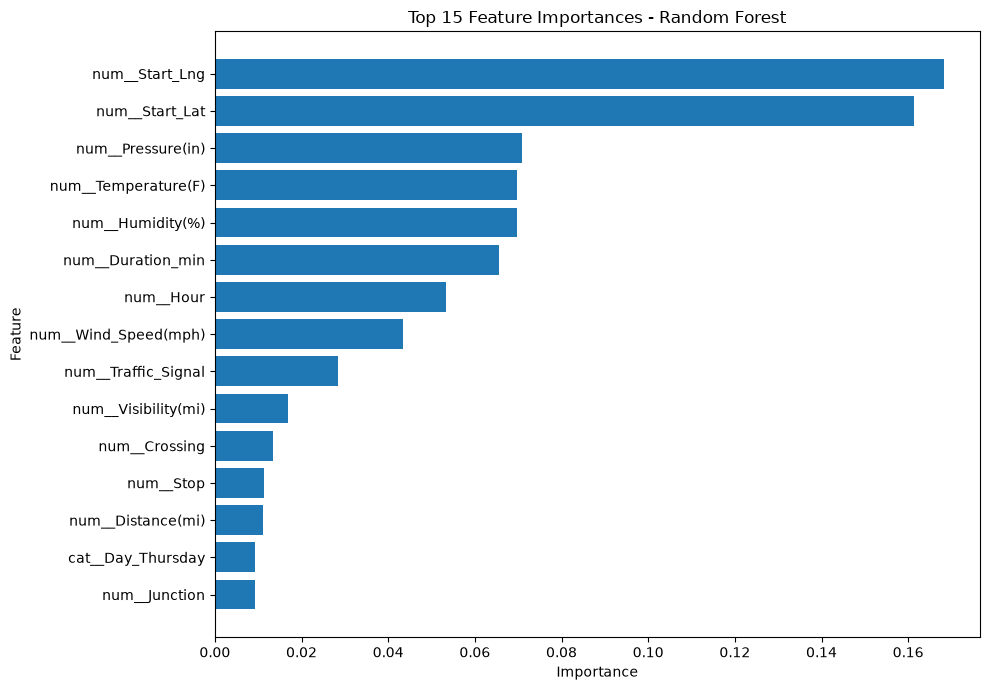

In [29]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

In [30]:
import joblib

joblib.dump(rf_strong, "accident_severity_model.pkl")

print("Model saved successfully.")

Model saved successfully.
